In [1]:
from synthetic.config import CurriculumStage
from synthetic.loaders.av2_loader import AV2ScenarioLoader
from synthetic.loaders.womd_loader import WOMDScenarioLoader
from synthetic.dataset import SyntheticCISSDataset
import os
from pathlib import Path
import random
import matplotlib.pyplot as plt
%matplotlib widget 
import matplotlib.patches as mpatches
import numpy as np

%load_ext autoreload
%autoreload 2

# av2_data_root = Path("../av2_test")
av2_data_root = Path("~/data/av2_motion/val").expanduser()
womd_data_root = Path("~/data/waymo_motion/validation/").expanduser()
# womd_data_root = Path("~/data/waymo/scenario/validation/validation.tfrecord-00000-of-00150").expanduser()

In [2]:
womd_loader = WOMDScenarioLoader(womd_data_root)
av2_loader = AV2ScenarioLoader(av2_data_root)

In [3]:
womd_dataset = SyntheticCISSDataset(womd_loader, CurriculumStage.NoRandomization, apply_pca=False, samples_per_scenario=1)

In [4]:
av2_dataset = SyntheticCISSDataset(av2_loader, CurriculumStage.NoRandomization)

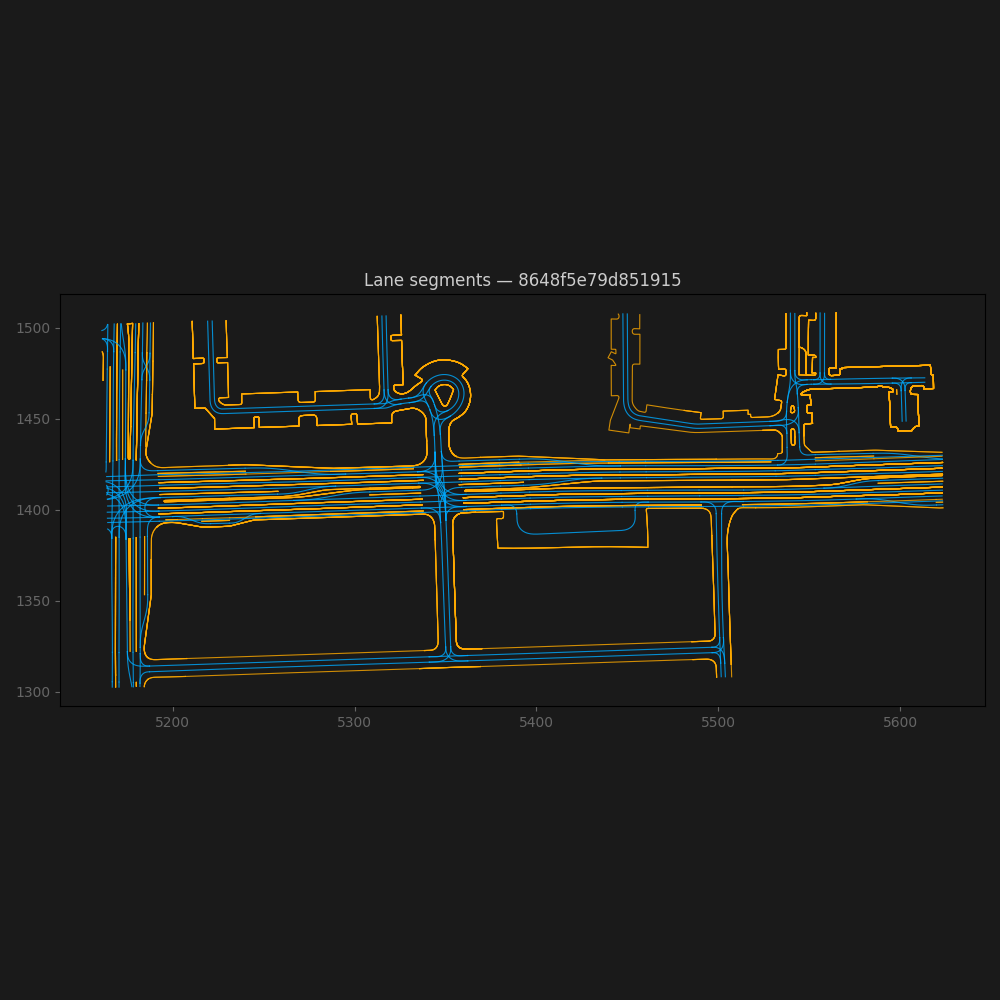

292 lane segments


In [5]:
segments, map_features = womd_loader.load_scenario("8648f5e79d851915")
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#1a1a1a")
ax.set_facecolor("#1a1a1a")
for seg in segments:
    for id_list in [seg.left_boundary_feature_ids, seg.right_boundary_feature_ids]:
        xy_lists = [map_features[feature_id].polyline_xy for feature_id in id_list]
        for xy in xy_lists:
            if xy.shape[0] >= 2:
                ax.plot(xy[:, 0], xy[:, 1], color="#ffaa00", linewidth=0.8, alpha=0.8)
    xy = seg.centerline_xy
    if xy.shape[0] >= 2:
        ax.plot(xy[:, 0], xy[:, 1], color="#00aaff", linewidth=0.8, alpha=0.8)
ax.set_aspect("equal", "box")
ax.set_title("Lane segments — 8648f5e79d851915", color="#cccccc")
ax.tick_params(colors="#666666")
plt.tight_layout()
plt.show()
print(f"{len(segments)} lane segments")


In [29]:
CLASS_COLORS = {
    "ROAD_EDGE":           "#2c2c2c",
    "LANE_MARKING_SOLID":  "#ffffff",
    "LANE_MARKING_DASHED": "#f0c040",
    "CROSSWALK_STRIPE":    "#a0c8ff",
    "STOP_LINE":           "#ff4040",
    "SHOULDER_LINE":       "#888888",
    "SIGN_SYMBOL":         "#ff9900",
    "ARROW_SYMBOL":        "#00ccff",
    "ANNOTATION_TEXT":     "#cc88ff",
    "ANNOTATION_GEOMETRY": "#88ffcc",
    "VEHICLE_OUTLINE":     "#ff6688",
    "IMPACT_MARKER":       "#ff0000",
    "OTHER":               "#aaaaaa",
}
CENTERLINE_COLOR = "#00ff88"
RAW_COLOR = "#aaaaaa"


def draw_scene(ax, scene, gt, title=None, show_centerlines=True, raw=False):
    """Draw a scene.

    raw=True: all elements in a neutral color, no centerlines (input view).
    raw=False: elements colored by GT class + optional centerlines (GT view).
    """
    ax.set_facecolor("#1a1a1a")
    ax.get_figure().patch.set_facecolor("#1a1a1a")

    for elem in scene.elements:
        pts = elem.resampled_points if elem.resampled_points else elem.control_points
        if not pts:
            continue
        xs = [p.x for p in pts]
        ys = [p.y for p in pts]
        if raw:
            ax.plot(xs, ys, color=RAW_COLOR, linewidth=1.0, solid_capstyle="round")
        else:
            cls = gt.element_classes.get(elem.id, "OTHER")
            color = CLASS_COLORS.get(cls, CLASS_COLORS["OTHER"])
            lw = 1.5 if cls in ("ROAD_EDGE", "SHOULDER_LINE") else 1.0
            ls = "--" if cls == "LANE_MARKING_DASHED" else "-"
            ax.plot(xs, ys, color=color, linewidth=lw, linestyle=ls, solid_capstyle="round")

    if show_centerlines and not raw:
        for centerline in gt.lane_centerlines.values():
            if not centerline:
                continue
            xs = [p.x for p in centerline]
            ys = [p.y for p in centerline]
            ax.plot(xs, ys, color=CENTERLINE_COLOR, linewidth=1.2, linestyle=":", alpha=0.8)

    ax.set_aspect("equal", "box")
    ax.tick_params(colors="#666666", labelsize=6)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    if title:
        ax.set_title(title, color="#cccccc", fontsize=8, pad=4)


def draw_scene_sidebyside(scene, gt, suptitle=None):
    fig, (ax_raw, ax_gt) = plt.subplots(
        1, 2, figsize=(14, 10), facecolor="#1a1a1a",
        gridspec_kw={"wspace": 0.06},
    )
    draw_scene(ax_raw, scene, gt, title="Input Scene", raw=True)
    draw_scene(ax_gt,  scene, gt, title="Ground Truth", show_centerlines=True)

    # Sync axes so both panels show the same region
    ax_gt.set_xlim(ax_raw.get_xlim())
    ax_gt.set_ylim(ax_raw.get_ylim())

    handles = [
        mpatches.Patch(color=c, label=cls.replace("_", " ").title())
        for cls, c in CLASS_COLORS.items()
    ]
    handles.append(mpatches.Patch(color=CENTERLINE_COLOR, label="Lane Centerline"))
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=7,
        fontsize=6,
        framealpha=0.4,
        facecolor="#111111",
        labelcolor="white",
        edgecolor="#555555",
        bbox_to_anchor=(0.5, -0.02),
    )
    if suptitle:
        fig.suptitle(suptitle, color="#cccccc", fontsize=10, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


def make_legend(ax):
    handles = [
        mpatches.Patch(color=c, label=cls.replace("_", " ").title())
        for cls, c in CLASS_COLORS.items()
    ]
    handles.append(mpatches.Patch(color=CENTERLINE_COLOR, label="Lane Centerline"))
    ax.legend(
        handles=handles,
        loc="upper right",
        fontsize=6,
        framealpha=0.4,
        facecolor="#111111",
        labelcolor="white",
        edgecolor="#555555",
        ncol=2,
    )


syn_5c14062cdca66b03_A_0


/tmp/ipykernel_2113628/3561933532.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


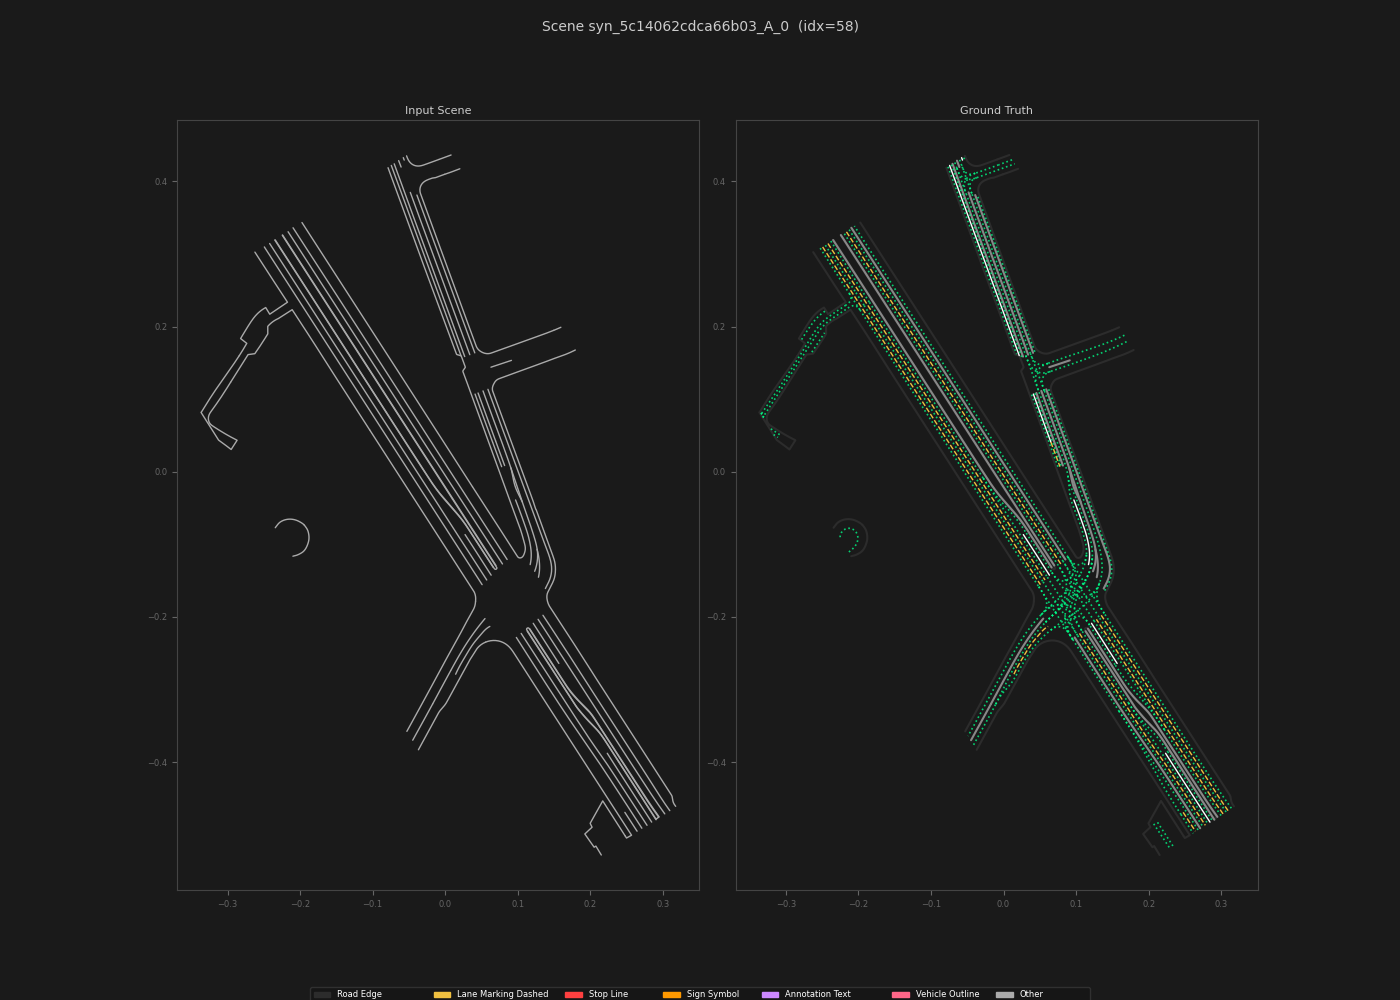

stage=A  elements=60  lanes=105


: 

In [ ]:
rng_idx = 58
scene, gt, inv_tf = womd_dataset[rng_idx]
print(scene.case_id)

draw_scene_sidebyside(scene, gt, suptitle=f"Scene {gt.scene_id}  (idx={rng_idx})")
plt.show()
print(f"stage={gt.curriculum_stage}  elements={len(scene.elements)}  lanes={len(gt.lane_centerlines)}")

/tmp/ipykernel_2113628/745040644.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


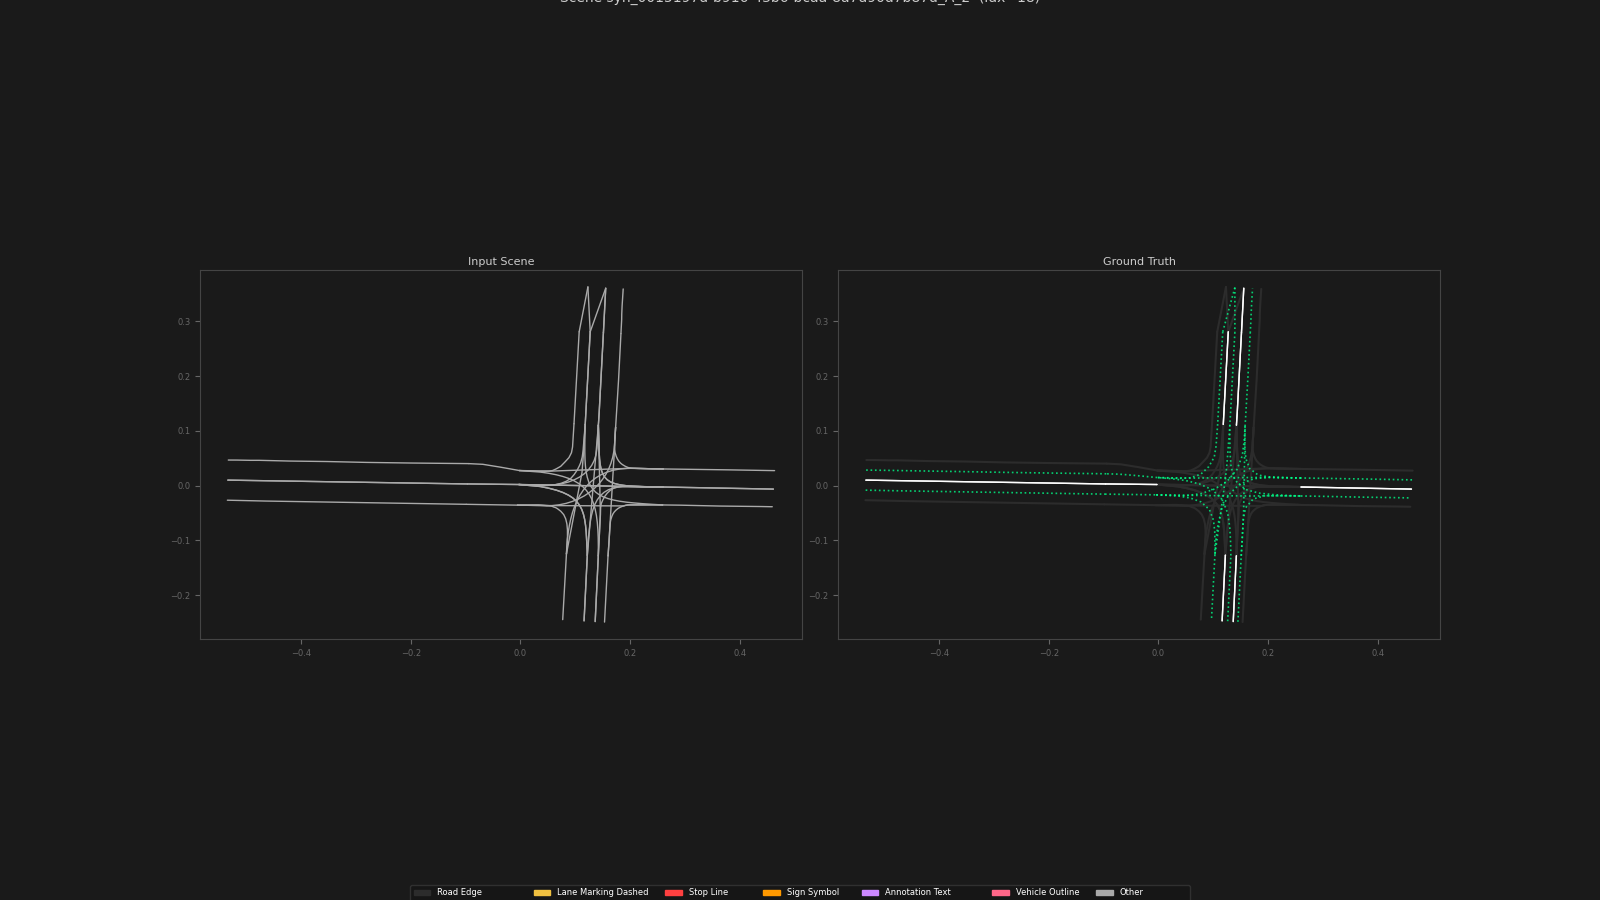

stage=A  elements=54  lanes=27


In [14]:
idx = 18
scene, gt, inv_tf = av2_dataset[idx]

draw_scene_sidebyside(scene, gt, suptitle=f"Scene {gt.scene_id}  (idx={idx})")
plt.show()
print(f"stage={gt.curriculum_stage}  elements={len(scene.elements)}  lanes={len(gt.lane_centerlines)}")

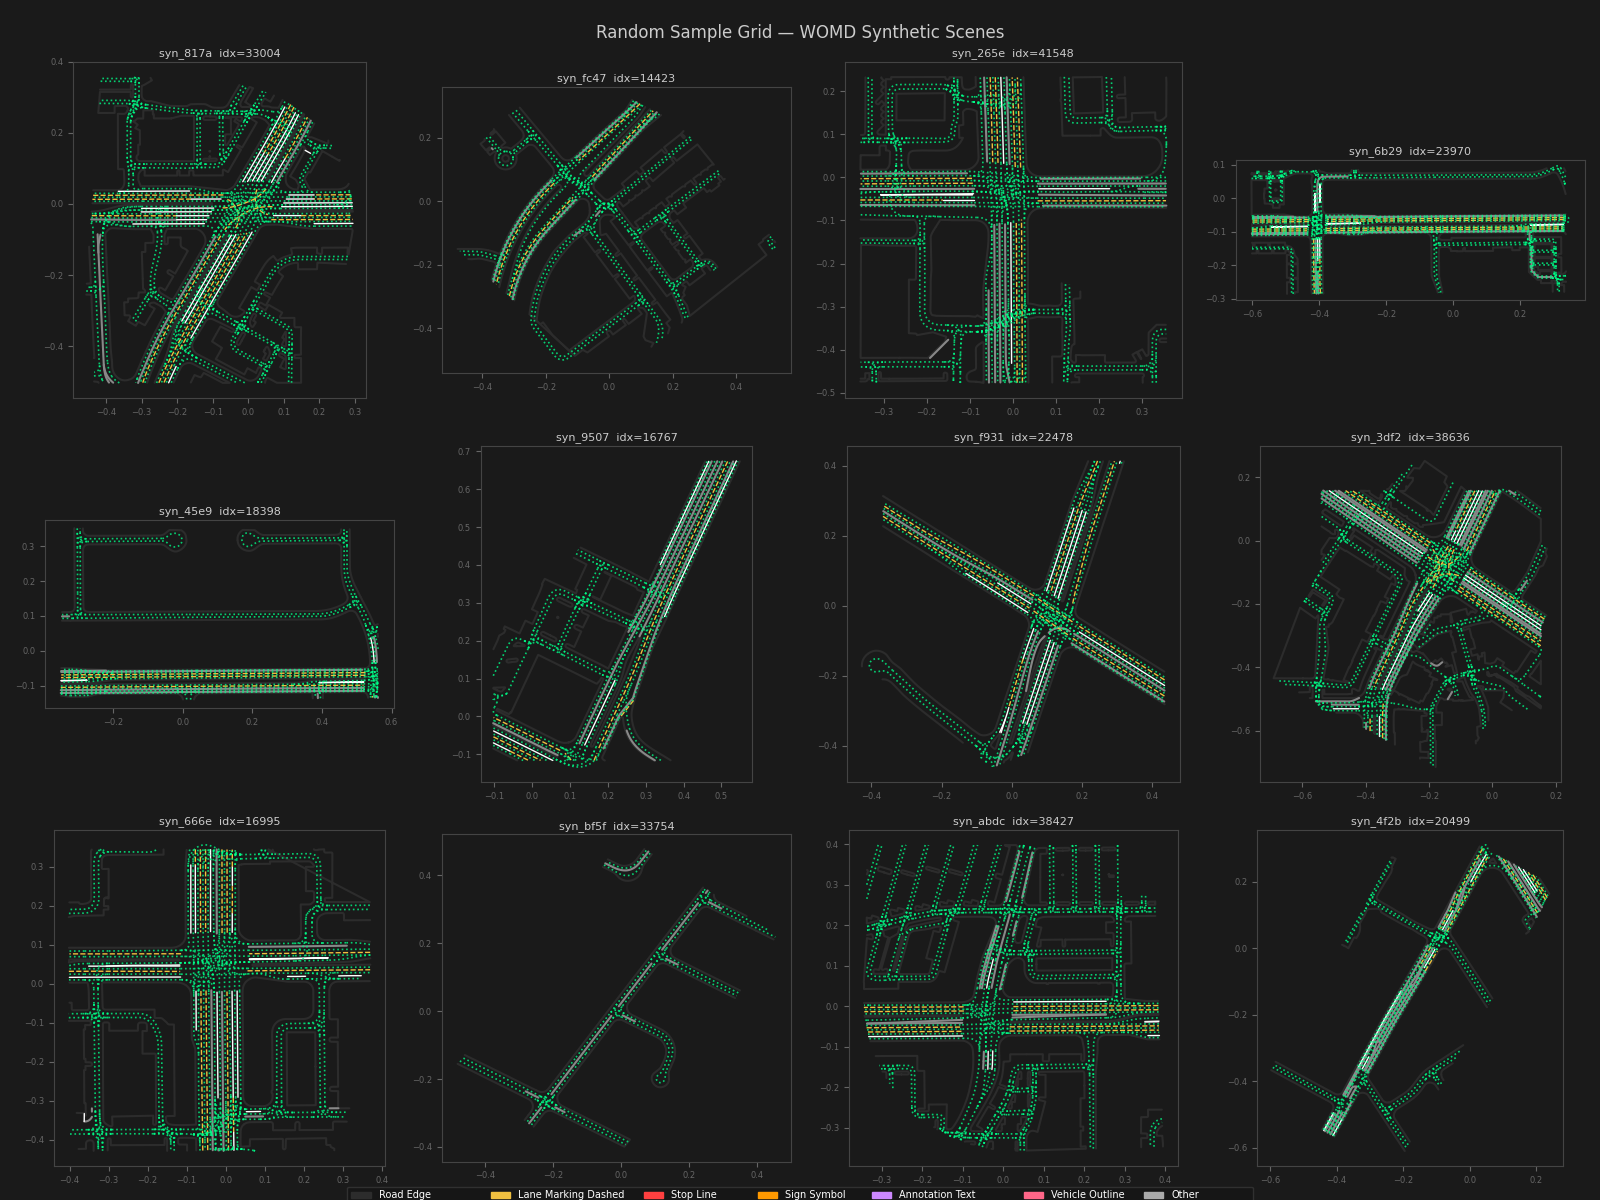

In [9]:
# ── Grid of N random samples ─────────────────────────────────────────────────
N_COLS = 4
N_ROWS = 3
N = N_COLS * N_ROWS

indices = random.sample(range(len(womd_dataset)), N)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 4, N_ROWS * 4),
    facecolor="#1a1a1a",
)
axes_flat = axes.flat


for ax, idx in zip(axes_flat, indices):
    s, g, _ = womd_dataset[idx]
    draw_scene(ax, s, g, title=f"{g.scene_id[:8]}  idx={idx}")

# Hide any unused axes
for ax in list(axes_flat)[N:]:
    ax.set_visible(False)
    

# Single shared legend below the grid
handles = [
    mpatches.Patch(color=c, label=cls.replace("_", " ").title())
    for cls, c in CLASS_COLORS.items()
]
handles.append(mpatches.Patch(color=CENTERLINE_COLOR, label="Lane Centerline"))
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=7,
    fontsize=7,
    framealpha=0.4,
    facecolor="#111111",
    labelcolor="white",
    edgecolor="#555555",
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle("Random Sample Grid — WOMD Synthetic Scenes", color="#cccccc", fontsize=12)
plt.tight_layout()
plt.show()

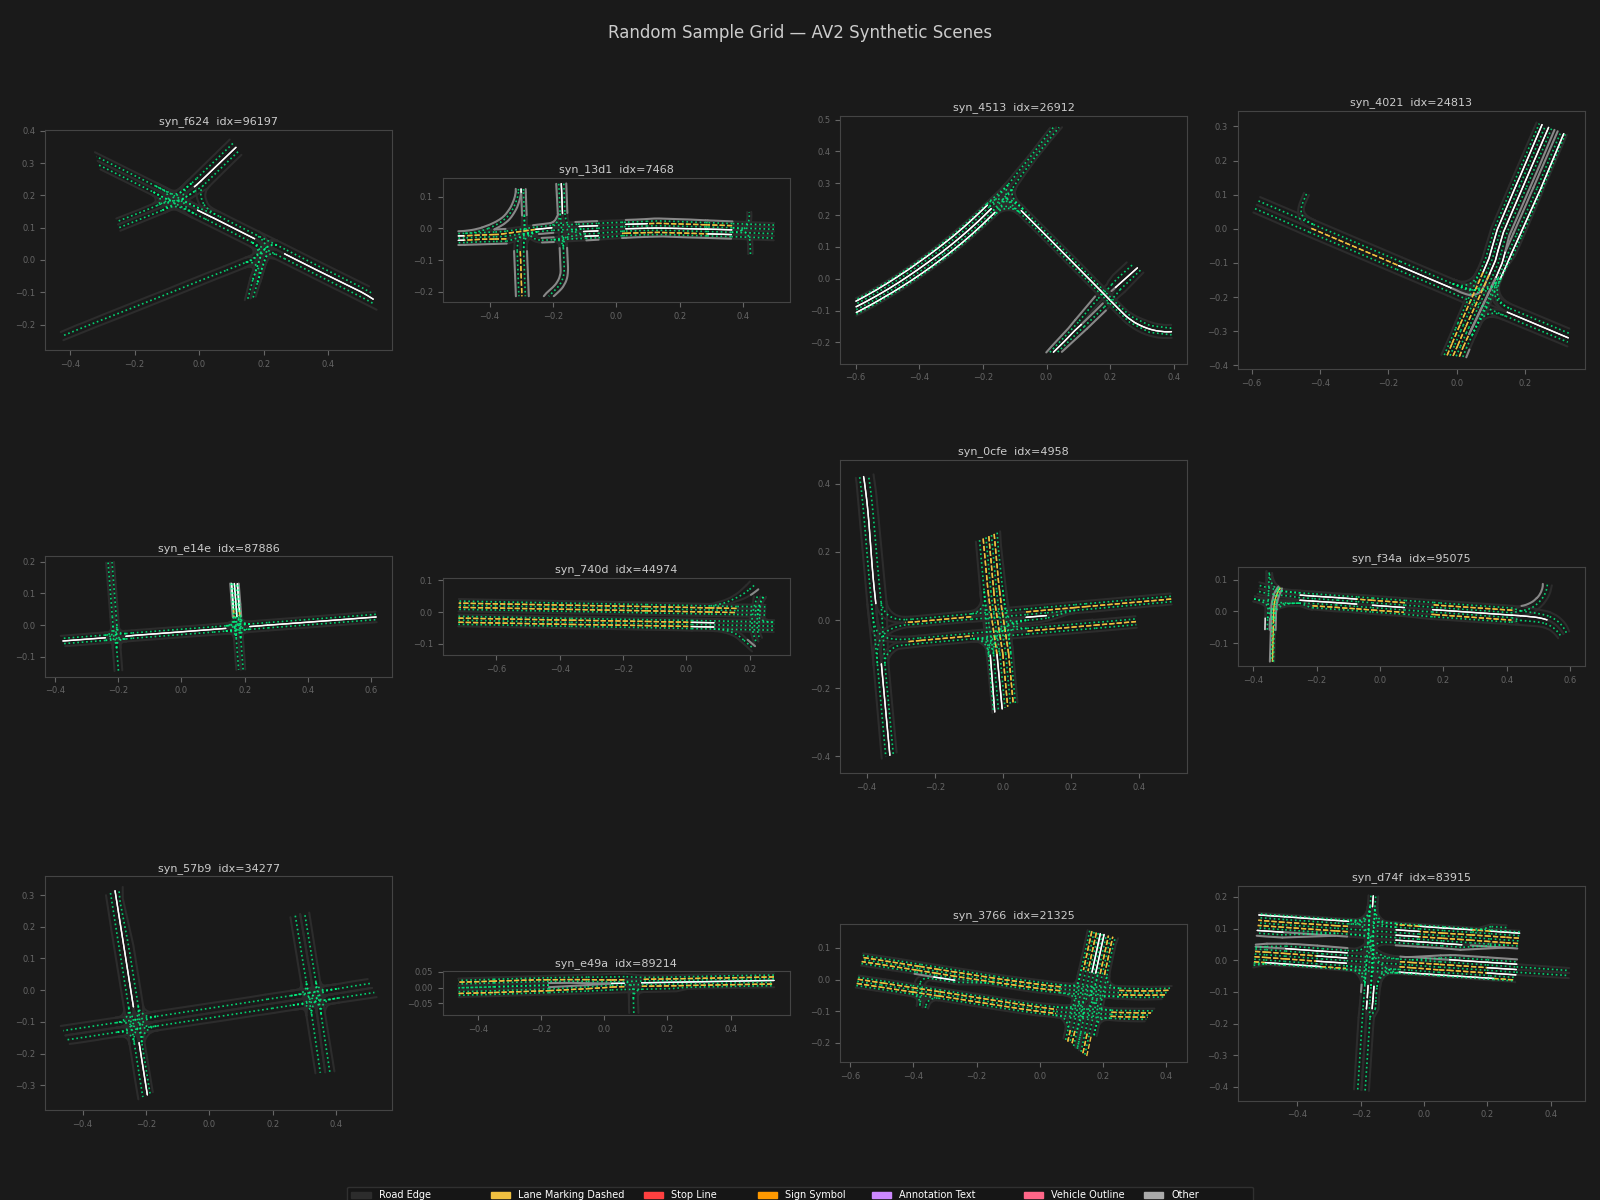

In [10]:
# ── Grid of N random samples ─────────────────────────────────────────────────
N_COLS = 4
N_ROWS = 3
N = N_COLS * N_ROWS

indices = random.sample(range(len(av2_dataset)), N)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 4, N_ROWS * 4),
    facecolor="#1a1a1a",
)
axes_flat = axes.flat


for ax, idx in zip(axes_flat, indices):
    s, g, _ = av2_dataset[idx]
    draw_scene(ax, s, g, title=f"{g.scene_id[:8]}  idx={idx}")

# Hide any unused axes
for ax in list(axes_flat)[N:]:
    ax.set_visible(False)
    

# Single shared legend below the grid
handles = [
    mpatches.Patch(color=c, label=cls.replace("_", " ").title())
    for cls, c in CLASS_COLORS.items()
]
handles.append(mpatches.Patch(color=CENTERLINE_COLOR, label="Lane Centerline"))
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=7,
    fontsize=7,
    framealpha=0.4,
    facecolor="#111111",
    labelcolor="white",
    edgecolor="#555555",
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle("Random Sample Grid — AV2 Synthetic Scenes", color="#cccccc", fontsize=12)
plt.tight_layout()
plt.show()